In [35]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)

In [13]:
class Option():
    def __init__(self,strike,expiration,type):
        self.strike = strike
        self.expiration = expiration
        self.type = type

In [ ]:
# Variables Required for the model
# 1) Option's strike price
# 2) Time to option's expiration
# 3) Type of option
# 4) Underlying asset's current price
# 5) Volatility of the market
# 6) Risk-free interest rate

def calculate_black_scholes_price(option,sigma,S,r,greeks=False):
    # Calculating risk-neutral price of an option
    K = option.strike
    t = option.expiration / 365
    d1 = (np.log(S/K) + (r + sigma**2 / 2) * t) / (sigma * np.sqrt(t))
    d2 = d1 - sigma * np.sqrt(t)
    call_price = S*norm.cdf(d1) - K * np.exp(-r*t)*norm.cdf(d2)
    put_price = K*np.exp(-r*t) * norm.cdf(-d2) - S*norm.cdf(-d1)
    vega = S*norm.pdf(d1) * np.sqrt(t)
    gamma = norm.pdf(d1) / (S*sigma*(np.sqrt(t)))
    if option.type == "call":
        if greeks:
            delta = norm.cdf(d1)
            rho = K * t *np.exp(-r*t)*norm.cdf(d2)
            theta = -(S*norm.pdf(d1)*sigma) / (2*np.sqrt(t)) - r*K*np.exp(-r*t)*norm.cdf(d2)
            return (call_price,[delta,gamma,theta,vega,rho])
        else:
            return call_price
            
    else:
        if greeks:
            delta = -norm.cdf(-d1)
            rho = - K * t *norm.cdf(-d2)
            theta = - (S*norm.pdf(d1)*sigma) / (2*np.sqrt(t)) + r*K*np.exp(-r*t)*norm.cdf(-d2)
            return (put_price,[delta,gamma,theta,vega,rho])
        else:
            return put_price

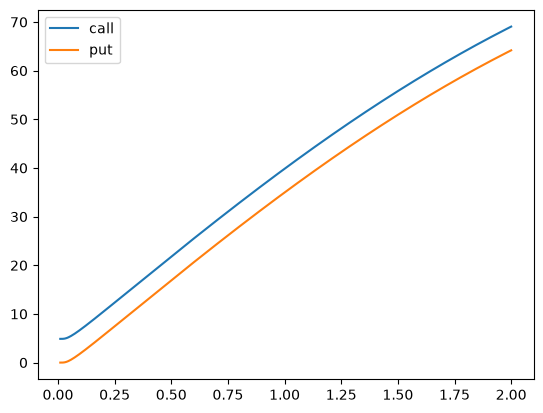

In [ ]:
K = 100
call_option = Option(K,365,"call")
put_option = Option(K,365,"put")
f = lambda x,y : calculate_black_scholes_price(y,x,100,0.05)
sigmas = np.linspace(0.01, 2, 500)
plt.plot(sigmas,f(sigmas,call_option),label='call')
plt.plot(sigmas,f(sigmas,put_option),label='put')
plt.legend(loc="upper left")

# The two graphs are identical, just translated due to the put-call parity
# Since we are holding all variables constant other than volatility, strike price - forward value is constant, so put - call is constant 

In [33]:
def price_path_gbm(s0,mu,sigma,T,dt):
    predictions = []
    s_t = s0
    for _ in np.arange(0,T,dt):
        s_t = s_t * np.exp(dt*(mu - 0.5 * sigma**2) + sigma * rng.normal(scale=np.sqrt(dt)))
        predictions.append(s_t)
    return predictions

In [ ]:
# Per contract (i.e 100 shares)
r  = 0.05
T = 1
price_path = price_path_gbm(100,0.05,0.1,1,1/365)
final_price = price_path[-1]
#plt.plot(np.arange(0,365),price_path)
#plt.plot(np.arange(0,365),[K]*365)
premium = calculate_black_scholes_price(call_option,0.1,100,0.05) * 100
payoff = max(final_price - K,0) * 100
pnl = payoff - premium
print(f"Premium Price : {premium}")
print(f"P/L : {pnl}")

Premium Price : 680.4957708822144
P/L : -680.4957708822144


In [94]:
calculate_black_scholes_price(call_option,0.1,100,0.05,greeks=True)
    

(np.float64(6.804957708822144),
 [np.float64(0.7088403132116536),
  np.float64(0.0342943855019384),
  np.float64(-4.918672955714081),
  np.float64(34.29438550193839),
  np.float64(64.07907361234322)])

In [ ]:
# Does Monte Carlo simulation converge to Black scholes?
default_μ  = 0.0001
default_ρ  = 0.1
default_ν  = 0.001
default_S0 = 10
default_h0 = 0
default_n = 10
default_β = 0.95
default_M = 100000

# Calculating option price using Monte Carlo + GBM model
payoffs = np.array([max(price_path_gbm(100,0.05,0.1,1,1/365)[-1] - K,0) for _ in range(0,default_M)])
price = np.exp(-0.05*1) * np.mean(payoffs) * 100
print(f"Option Price = {price}")


Option Price = 684.7941685121227
